WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


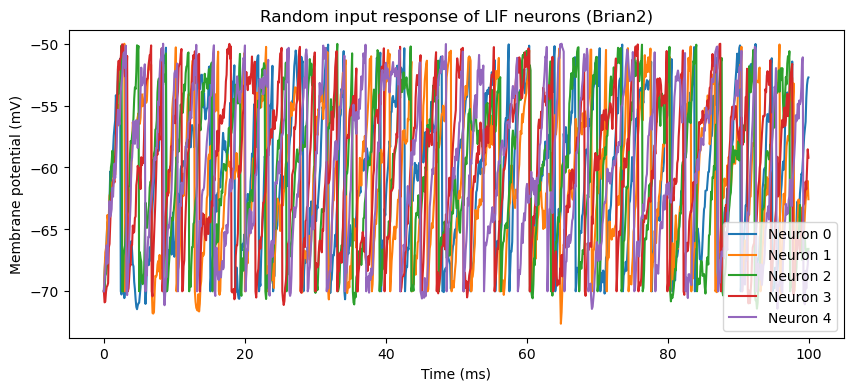

In [6]:
import numpy as np
from brian2 import *
import matplotlib.pyplot as plt

start_scope()

# --- パラメータ設定 ---
tau_m = 10 * ms
R_m = 100 * Mohm

# --- ニューロン方程式 ---
eqs = '''
dv/dt = (-v + R_m * I_exc) / tau_m : volt
I_exc : amp
'''

# --- ニューロングループ作成 ---
G_res = NeuronGroup(100, eqs, threshold='v > -50*mV', reset='v = -70*mV', method='euler')
G_res.v = -70*mV  # 初期膜電位

# --- 記録設定 ---
M = StateMonitor(G_res, 'v', record=True)

# --- 外部入力（ランダム電流） ---
@network_operation(dt=0.1*ms)
def apply_input():
    G_res.I_exc = np.random.randn(100) * nA

# --- シミュレーション実行 ---
run(100*ms)

# --- 可視化 ---
plt.figure(figsize=(10,4))
for i in range(5):  # 5個のニューロンをプロット
    plt.plot(M.t/ms, M.v[i]/mV, label=f'Neuron {i}')
plt.xlabel('Time (ms)')
plt.ylabel('Membrane potential (mV)')
plt.title('Random input response of LIF neurons (Brian2)')
plt.legend()
plt.show()


WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/ (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


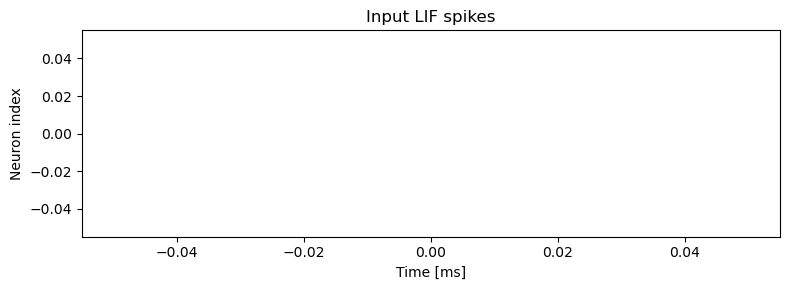

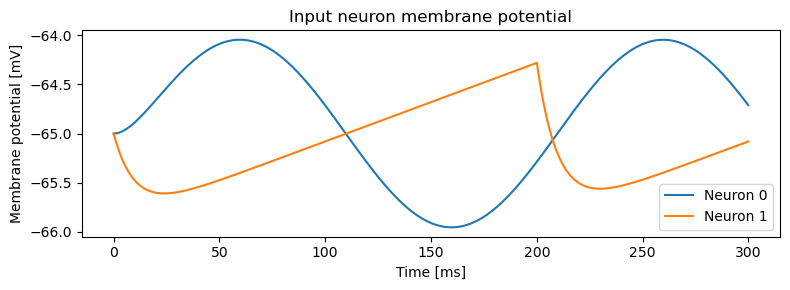

In [1]:
# ======================================
# Brian2: 連続値入力 → LIFニューロンのスパイク化
# ======================================
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# パラメータ設定
# ----------------------------
defaultclock.dt = 0.1*ms

N_in = 2  # 入力チャネル数（例：メルケルとマイスナー）
T = 300*ms

# LIFパラメータ
v_rest = -65*mV
v_reset = -65*mV
v_thr = -50*mV
tau_m = 10*ms
t_ref = 2*ms

# ----------------------------
# 擬似的な連続入力信号
# ----------------------------
dt_data = float(defaultclock.dt/second)
nt = int(T/second / dt_data)
t_array = np.arange(nt) * dt_data

# サンプル：正弦波とノコギリ波
I0 = 1.0 * np.sin(2*np.pi*5*t_array)
I1 = 0.8 * (2*(t_array*5 % 1) - 1)
input_current = np.vstack([I0, I1]) * mV  # (2, nt)

# ----------------------------
# TimedArrayでBrian2に渡す
# ----------------------------
stimulus = TimedArray(input_current.T, dt=defaultclock.dt)

# ----------------------------
# LIFニューロン群の定義
# ----------------------------
eqs_in = '''
dv/dt = (-(v - v_rest) + I_drive)/tau_m : volt (unless refractory)
I_drive = stimulus(t, i) : volt  # 時刻tの入力信号を各ニューロンに与える
'''

G_in = NeuronGroup(
    N_in, eqs_in,
    threshold='v > v_thr',
    reset='v = v_reset',
    refractory=t_ref,
    method='euler'
)

G_in.v = v_rest  # 初期値

# ----------------------------
# モニタ
# ----------------------------
M_spike = SpikeMonitor(G_in)
M_v = StateMonitor(G_in, 'v', record=True)

# ----------------------------
# 実行
# ----------------------------
run(T)

# ----------------------------
# 結果表示
# ----------------------------
plt.figure(figsize=(8,3))
plt.plot(M_spike.t/ms, M_spike.i, 'r.', ms=8)
plt.xlabel('Time [ms]')
plt.ylabel('Neuron index')
plt.title('Input LIF spikes')
plt.tight_layout()

plt.figure(figsize=(8,3))
for i in range(N_in):
    plt.plot(M_v.t/ms, M_v.v[i]/mV, label=f'Neuron {i}')
plt.xlabel('Time [ms]')
plt.ylabel('Membrane potential [mV]')
plt.legend()
plt.title('Input neuron membrane potential')
plt.tight_layout()
plt.show()


In [11]:
from brian2 import *

start_scope()

G = NeuronGroup(1, 'dv/dt = -v/(10*ms) : 1')
M = StateMonitor(G, 'v', record=True)

@network_operation(dt=10*ms)
def report_time():
    print("現在時刻:", defaultclock.t)

run(50*ms)



INFO       No numerical integration method specified for group 'neurongroup_1', using method 'exact' (took 0.25s). [brian2.stateupdaters.base.method_choice]


現在時刻: <defaultclock.t: 0. * second>
現在時刻: <defaultclock.t: 10. * msecond>
現在時刻: <defaultclock.t: 20. * msecond>
現在時刻: <defaultclock.t: 30. * msecond>
現在時刻: <defaultclock.t: 40. * msecond>


WARNING    'i' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 4. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


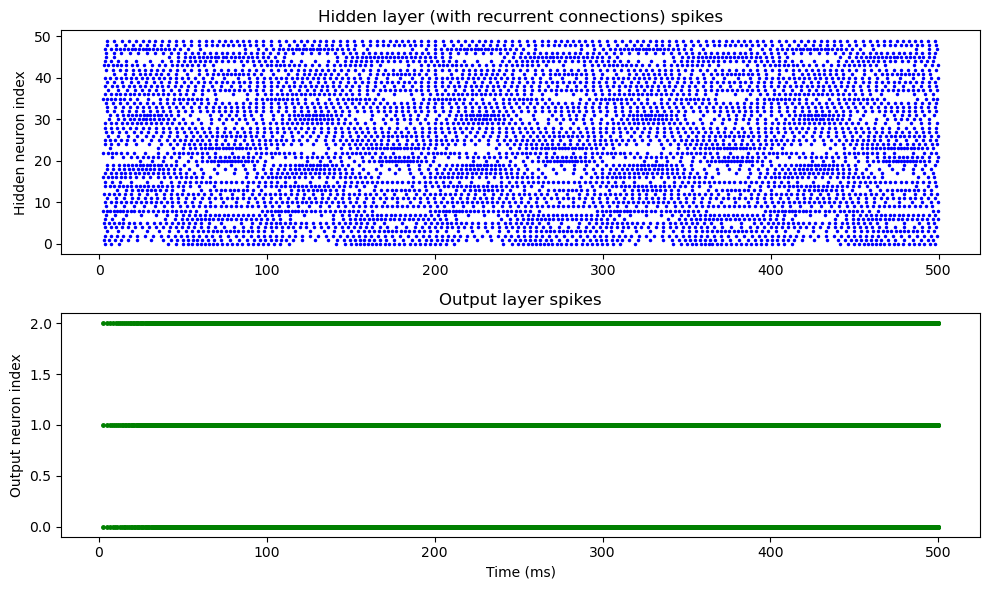

In [16]:
from brian2 import *
import numpy as np

start_scope()

# =====================================
# 1️⃣ 基本パラメータ設定
# =====================================
defaultclock.dt = 0.1*ms        # シミュレーション刻み幅
dt_data = 0.1e-3                # 時系列入力の刻み (秒単位)

N_in = 2       # 入力チャネル（例：Merkel, Meissner）
N_hidden = 50  # 中間層ニューロン数（リザーバ）
N_out = 3      # 出力層ニューロン数

BIAS = -65     # リセット電位と同じバイアス
runtime = 0.5  # 総シミュレーション時間 [s]（5000サンプル）

# =====================================
# 2️⃣ 時系列データを作成（例: sin波 + ノイズ）
# =====================================
nt = int(runtime / dt_data)      # = 5000
t_array = np.arange(nt) * dt_data

# 2チャネルの時系列信号
input_current = np.zeros((N_in, nt))
input_current[0, :] = 0.5*np.sin(2*np.pi*10*t_array) + 0.1*np.random.randn(nt)
input_current[1, :] = 0.3*np.sin(2*np.pi*20*t_array + 1) + 0.1*np.random.randn(nt)

# 入力→中間層結合（正規化済みランダム重み）
w_in = np.random.randn(N_in, N_hidden) * 1.0

# =====================================
# 3️⃣ LIF ニューロンモデル定義
# =====================================
eqs_hidden = '''
dv/dt = (-v + I_exc - I_inh) / (10*ms) : volt
I_exc : volt
I_inh : volt
'''

eqs_out = '''
dv/dt = (-v + I_exc - I_inh) / (10*ms) : volt
I_exc : volt
I_inh : volt
'''

# --- 中間層 ---
hidden = NeuronGroup(N_hidden, eqs_hidden,
                     threshold='v>-45*mV',  # 閾値を少し緩める
                     reset='v=-65*mV',
                     method='euler')
hidden.v = -65*mV

# --- 出力層 ---
output = NeuronGroup(N_out, eqs_out,
                     threshold='v>-50*mV',
                     reset='v=-65*mV',
                     method='euler')
output.v = -65*mV
output.I_exc = 0*mV
output.I_inh = 0*mV

# =====================================
# 4️⃣ シナプス結合（入力→中間→出力＋再帰）
# =====================================
# 中間層の再帰結合
S_rec = Synapses(hidden, hidden, on_pre='I_exc_post += 2.0*mV')
S_rec.connect(condition='i != j', p=0.1)

# 中間層→出力層
S_hidden_out = Synapses(hidden, output, on_pre='I_exc_post += 3*mV')
S_hidden_out.connect(p=0.2)

# =====================================
# 5️⃣ 時系列データを Brian2 に注入
# =====================================
@network_operation(dt=dt_data*second)
def apply_input():
    # 現在のシミュレーション時刻に対応するインデックス
    idx = int(defaultclock.t / (dt_data*second))
    if idx < nt:
        # 入力電流を中間層へ投影
        I_input = input_current[:, idx] @ w_in
        # 電流を増幅して膜電位を閾値近くまで引き上げる
        hidden.I_exc = (I_input * 50 + BIAS + 60) * mV
        hidden.I_inh = 0 * mV
    else:
        hidden.I_exc = 0 * mV
        hidden.I_inh = 0 * mV

# =====================================
# 6️⃣ モニタと実行
# =====================================
M_hidden = SpikeMonitor(hidden)
M_out = SpikeMonitor(output)

duration = nt * dt_data * second  # 0.5 秒
net = Network(hidden, output, S_rec, S_hidden_out, apply_input, M_hidden, M_out)
net.run(duration)

# =====================================
# 7️⃣ 可視化
# =====================================
figure(figsize=(10,6))

subplot(2,1,1)
plot(M_hidden.t/ms, M_hidden.i, 'b.', markersize=3)
ylabel('Hidden neuron index')
title('Hidden layer (with recurrent connections) spikes')

subplot(2,1,2)
plot(M_out.t/ms, M_out.i, 'g.', markersize=5)
xlabel('Time (ms)')
ylabel('Output neuron index')
title('Output layer spikes')

tight_layout()
show()



WARNING    'i' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 2. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'j' is an internal variable of group 'synapses_5', but also exists in the run namespace with the value 1. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


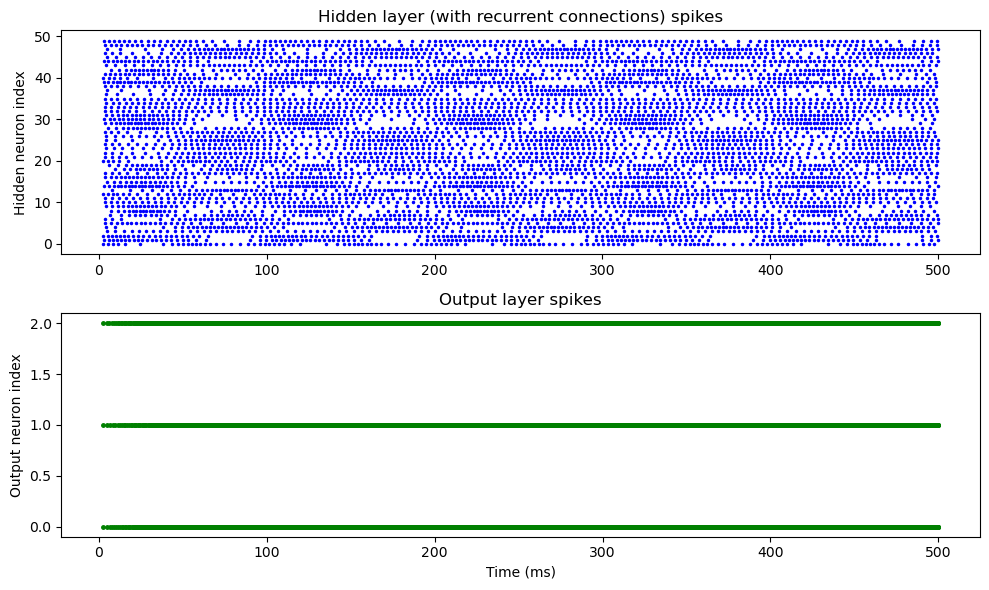

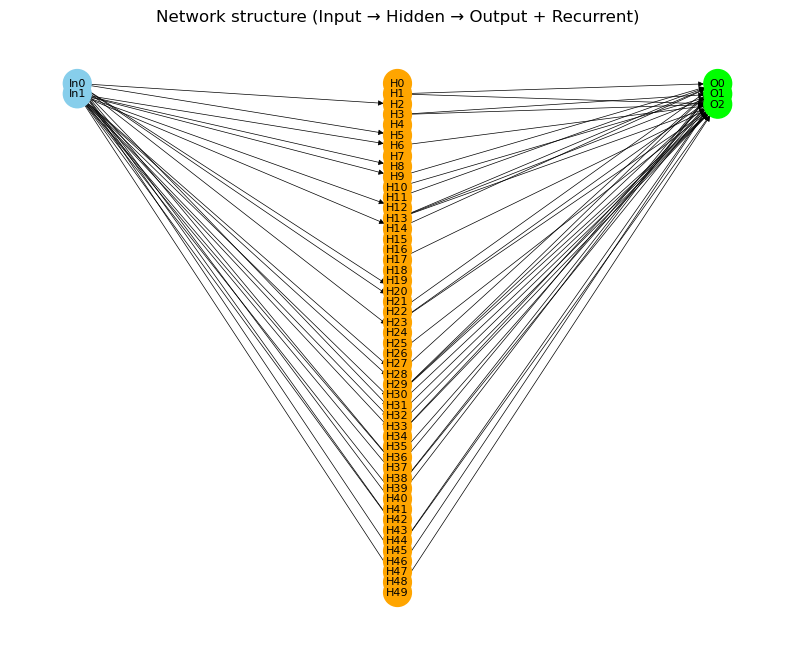

In [18]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

start_scope()

# =====================================
# 1️⃣ 基本パラメータ設定
# =====================================
defaultclock.dt = 0.1*ms
dt_data = 0.1e-3  # 秒単位 (0.1 ms)

N_in = 2        # 入力チャネル
N_hidden = 50   # 中間層（リザーバ）
N_out = 3       # 出力層
BIAS = -65
runtime = 0.5   # シミュレーション時間 [s]

# =====================================
# 2️⃣ 時系列データを生成（sin波＋ノイズ）
# =====================================
nt = int(runtime / dt_data)  # = 5000
t_array = np.arange(nt) * dt_data

input_current = np.zeros((N_in, nt))
input_current[0, :] = 0.5*np.sin(2*np.pi*10*t_array) + 0.1*np.random.randn(nt)
input_current[1, :] = 0.3*np.sin(2*np.pi*20*t_array + 1) + 0.1*np.random.randn(nt)

w_in = np.random.randn(N_in, N_hidden) * 1.0

# =====================================
# 3️⃣ LIF ニューロンモデル定義
# =====================================
eqs_hidden = '''
dv/dt = (-v + I_exc - I_inh) / (10*ms) : volt
I_exc : volt
I_inh : volt
'''

eqs_out = '''
dv/dt = (-v + I_exc - I_inh) / (10*ms) : volt
I_exc : volt
I_inh : volt
'''

# --- 中間層 ---
hidden = NeuronGroup(N_hidden, eqs_hidden,
                     threshold='v>-45*mV',
                     reset='v=-65*mV',
                     method='euler')
hidden.v = -65*mV

# --- 出力層 ---
output = NeuronGroup(N_out, eqs_out,
                     threshold='v>-50*mV',
                     reset='v=-65*mV',
                     method='euler')
output.v = -65*mV
output.I_exc = 0*mV
output.I_inh = 0*mV

# =====================================
# 4️⃣ シナプス結合（入力→中間→出力＋再帰）
# =====================================
# 中間層の再帰結合
S_rec = Synapses(hidden, hidden, on_pre='I_exc_post += 2.0*mV')
S_rec.connect(condition='i != j', p=0.1)

# 中間層→出力層
S_hidden_out = Synapses(hidden, output, on_pre='I_exc_post += 3*mV')
S_hidden_out.connect(p=0.2)

# =====================================
# 5️⃣ 時系列データを入力として注入
# =====================================
@network_operation(dt=dt_data*second)
def apply_input():
    idx = int(defaultclock.t / (dt_data*second))
    if idx < nt:
        I_input = input_current[:, idx] @ w_in
        hidden.I_exc = (I_input * 50 + BIAS + 60) * mV
        hidden.I_inh = 0 * mV
    else:
        hidden.I_exc = 0 * mV
        hidden.I_inh = 0 * mV

# =====================================
# 6️⃣ モニタと実行
# =====================================
M_hidden = SpikeMonitor(hidden)
M_out = SpikeMonitor(output)

duration = nt * dt_data * second  # 0.5 s
net = Network(hidden, output, S_rec, S_hidden_out, apply_input, M_hidden, M_out)
net.run(duration)

# =====================================
# 7️⃣ スパイク可視化
# =====================================
plt.figure(figsize=(10,6))

plt.subplot(2,1,1)
plt.plot(M_hidden.t/ms, M_hidden.i, 'b.', markersize=3)
plt.ylabel('Hidden neuron index')
plt.title('Hidden layer (with recurrent connections) spikes')

plt.subplot(2,1,2)
plt.plot(M_out.t/ms, M_out.i, 'g.', markersize=5)
plt.xlabel('Time (ms)')
plt.ylabel('Output neuron index')
plt.title('Output layer spikes')

plt.tight_layout()
plt.show()

# =====================================
# 8️⃣ ネットワーク構造の可視化
# =====================================
G = nx.DiGraph()

# ノード追加
for i in range(N_in):
    G.add_node(f"In{i}", layer="input")
for i in range(N_hidden):
    G.add_node(f"H{i}", layer="hidden")
for i in range(N_out):
    G.add_node(f"O{i}", layer="output")

# 入力→中間層（簡易的にランダム表示）
for i in range(N_in):
    for j in range(N_hidden):
        if np.random.rand() < 0.15:
            G.add_edge(f"In{i}", f"H{j}")

# 中間層内再帰結合
for i, j in zip(S_rec.i[:], S_rec.j[:]):
    G.add_edge(f"H{i}", f"H{j}")

# 中間→出力層
for i, j in zip(S_hidden_out.i[:], S_hidden_out.j[:]):
    G.add_edge(f"H{i}", f"O{j}")

# レイヤーごとの配置座標を定義
pos = {}
for i in range(N_in):
    pos[f"In{i}"] = (-1, -i)
for i in range(N_hidden):
    pos[f"H{i}"] = (0, -i)
for i in range(N_out):
    pos[f"O{i}"] = (1, -i)

# === 安全な Matplotlib 描画方式 ===
fig, ax = plt.subplots(figsize=(10,8))
nx.draw(G, pos, ax=ax,
        with_labels=True,
        node_size=400,
        font_size=8,
        node_color=['skyblue' if 'In' in n else 'orange' if 'H' in n else 'lime' for n in G.nodes()],
        arrowsize=8, width=0.5)
ax.set_title("Network structure (Input → Hidden → Output + Recurrent)")
ax.axis('off')
plt.show()


INFO       No numerical integration method specified for group 'neurongroup_2', using method 'exact' (took 0.02s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'neurongroup_3', using method 'exact' (took 0.00s). [brian2.stateupdaters.base.method_choice]


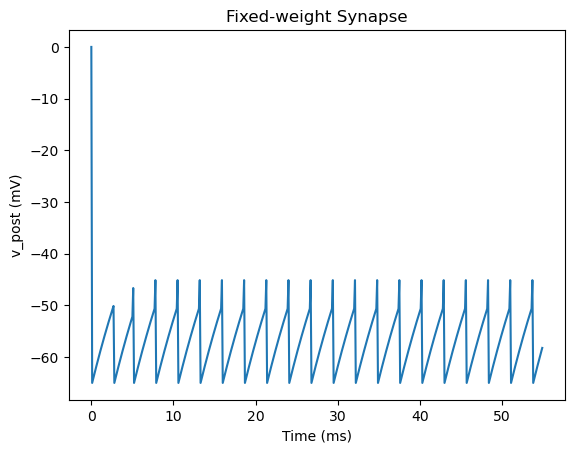

In [19]:
from brian2 import *

start_scope()

# ニューロン群
G1 = NeuronGroup(1, 'dv/dt = -v / (10*ms) : volt', threshold='v>-50*mV', reset='v=-65*mV')
G2 = NeuronGroup(1, 'dv/dt = -v / (10*ms) : volt', threshold='v>-50*mV', reset='v=-65*mV')

# シナプス（G1→G2）
S = Synapses(G1, G2, model='w : volt', on_pre='v_post += w')
S.connect()        # 全結合（1対1）
S.w = 5*mV         # 重み設定

# モニタ
M = StateMonitor(G2, 'v', record=True)

# スパイク生成
run(5*ms)
G1.v = -40*mV      # 手動で発火させる
run(50*ms)

plot(M.t/ms, M.v[0]/mV)
xlabel('Time (ms)')
ylabel('v_post (mV)')
title('Fixed-weight Synapse')
show()


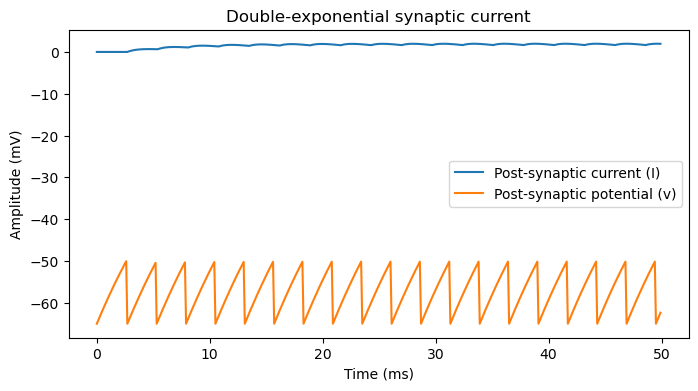

In [20]:
from brian2 import *

start_scope()

# --------------------------
# ニューロンモデル
# --------------------------
eqs = '''
dv/dt = (-v + I) / (10*ms) : volt
dI/dt = -I / tau_d + x / tau_r : volt
dx/dt = -x / tau_r : volt
'''

# パラメータ
tau_r = 1*ms   # 立ち上がり
tau_d = 5*ms   # 減衰
N = 2

G = NeuronGroup(N, eqs, threshold='v>-50*mV', reset='v=-65*mV', method='euler')
G.v = -65*mV

# --------------------------
# シナプス（双指数型電流）
# --------------------------
S = Synapses(G, G,
             model='w : volt',
             on_pre='''
             x_post += w
             ''')
S.connect(i=0, j=1)
S.w = 1.0*mV  # 重み

# --------------------------
# モニタ
# --------------------------
M = StateMonitor(G, ['v', 'I'], record=True)
spikemon = SpikeMonitor(G)

run(50*ms)

# --------------------------
# 可視化
# --------------------------
figure(figsize=(8,4))
plot(M.t/ms, M.I[1]/mV, label='Post-synaptic current (I)')
plot(M.t/ms, M.v[1]/mV, label='Post-synaptic potential (v)')
xlabel('Time (ms)')
ylabel('Amplitude (mV)')
legend()
title('Double-exponential synaptic current')
show()
